<a href="https://colab.research.google.com/github/kshitijagame-tech/rabtech-aiml-customer-churn/blob/main/Task_3_Feature_Engineering_Preprocessing_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import seaborn as sns

# Load Titanic dataset
df = sns.load_dataset("titanic")

# Display first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# Check dataset shape
print("Dataset shape:", df.shape)

# Check column names
print("\nColumns:")
print(df.columns.tolist())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (891, 15)

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [ ]:
# Remove unnecessary columns
df = df.drop(columns=["alive", "class", "deck"], errors="ignore")

# Define target variable
y = df["survived"]

# Define input features
X = df.drop(columns=["survived"])

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (891, 11)
Target (y): (891,)


In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 11)
Testing data: (179, 11)


In [ ]:
# Identify numerical and categorical columns

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical features:
['sex', 'embarked', 'who', 'adult_male', 'embark_town', 'alone']


In [ ]:
# Numerical preprocessing pipeline
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

print("Preprocessing pipelines created successfully!")

Preprocessing pipelines created successfully!


In [ ]:
# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("ColumnTransformer created successfully!")

ColumnTransformer created successfully!


In [ ]:
# Create complete machine learning pipeline
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

print("Complete ML pipeline created successfully!")

Complete ML pipeline created successfully!


In [ ]:
# Train the complete pipeline
model_pipeline.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
# Make predictions on test data
y_pred = model_pipeline.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", round(accuracy * 100, 2), "%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 81.01 %

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



In [ ]:
# Get feature names after preprocessing
feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance from Random Forest
importances = model_pipeline.named_steps["classifier"].feature_importances_

# Create a DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
feature_importance.head(15)

,Feature,Importance
4,num__fare,0.244464
1,num__age,0.211311
0,num__pclass,0.077754
11,cat__who_man,0.074013
13,cat__adult_male_False,0.069121
14,cat__adult_male_True,0.062326
5,cat__sex_female,0.053273
6,cat__sex_male,0.052992
2,num__sibsp,0.049000
3,num__parch,0.031686


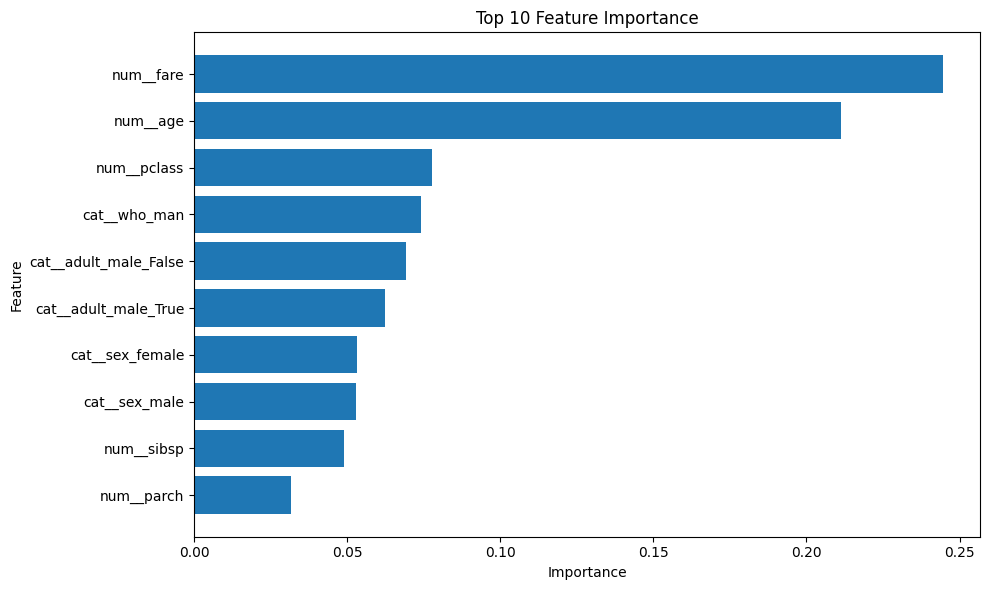

In [ ]:
import matplotlib.pyplot as plt

# Select top 10 important features
top_features = feature_importance.head(10)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Transform the training and testing data using the preprocessing pipeline

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (712, 20)
Processed testing data shape: (179, 20)


In [ ]:
# Verify that the complete pipeline works on unseen test data

test_predictions = model_pipeline.predict(X_test)

print("Pipeline verification successful!")
print("Number of test samples:", len(X_test))
print("Number of predictions:", len(test_predictions))

Pipeline verification successful!
Number of test samples: 179
Number of predictions: 179


In [ ]:
print("========== TASK 3 SUMMARY ==========")
print("Dataset: Titanic")
print("Preprocessing: Imputation + Standard Scaling + One-Hot Encoding")
print("Data Split: 80% Training / 20% Testing")
print("Model: Random Forest Classifier")
print("Feature Importance: Random Forest")
print("Data Leakage: Prevented using Pipeline and Train/Test Split")
print("====================================")

========== TASK 3 SUMMARY ==========
Dataset: Titanic
Preprocessing: Imputation + Standard Scaling + One-Hot Encoding
Data Split: 80% Training / 20% Testing
Model: Random Forest Classifier
Feature Importance: Random Forest
Data Leakage: Prevented using Pipeline and Train/Test Split
